# CNN Challenge Model 2: ConvNeXt-Tiny


## 1. Imports & Setup

In [8]:
# Core imports
from pathlib import Path
import random
import time
import copy

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split
from torchvision import datasets, transforms
from torchvision.transforms import v2

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

PyTorch version: 2.11.0+cu130
CUDA available: True


In [2]:
# Import ConvNeXt-Tiny with pretrained weights
from torchvision.models import convnext_tiny, ConvNeXt_Tiny_Weights

In [3]:
# Mount Google Drive
try:
    from google.colab import drive
    drive.mount('/content/gdrive')
except ImportError:
    print("Not running in Google Colab; Drive mount skipped.")

Mounted at /content/gdrive


In [4]:
# Path set to assignment directory

PROJECT_ROOT = Path('/content/gdrive/MyDrive/ITCS_6169/assignment1')
DATA_ROOT = PROJECT_ROOT / 'data'
TRAIN_ROOT = DATA_ROOT / 'train'
TEST_ROOT = DATA_ROOT / 'test'

print('Project root:', PROJECT_ROOT.resolve())
print('Training data:', TRAIN_ROOT)
print('Testing data:', TEST_ROOT)

Project root: /content/gdrive/MyDrive/ITCS_6169/assignment1
Training data: /content/gdrive/MyDrive/ITCS_6169/assignment1/data/train
Testing data: /content/gdrive/MyDrive/ITCS_6169/assignment1/data/test


In [5]:
SEED = 0

def set_random_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_random_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

Using device: cuda


## 2. Preprocessing

In [11]:
IMG_SIZE = 224
BATCH_SIZE = 64
VAL_FRACTION = 0.20

# 1. Define distinct transforms
# Use official weights default transforms for Val/Test
weights = ConvNeXt_Tiny_Weights.DEFAULT

# Data Augmentation
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.v2.RandomErasing( p=0.25, scale=(0.02, 0.33), ratio=(0.3, 3.3), value=0.0, inplace=False),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = weights.transforms()

# 2. Wrapper class to apply transforms after random_split
class TransformedDataset(Dataset):
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform

    def __getitem__(self, index):
        x, y = self.subset[index]
        if self.transform:
            x = self.transform(x)
        return x, y

    def __len__(self):
        return len(self.subset)

# Load base dataset without transforms (returns PIL Images)
raw_train_dataset = datasets.ImageFolder(TRAIN_ROOT, transform=None)
test_dataset = datasets.ImageFolder(TEST_ROOT, transform=val_transform)

class_names = raw_train_dataset.classes
num_classes = len(class_names)

val_size = int(round(len(raw_train_dataset) * VAL_FRACTION))
train_size = len(raw_train_dataset) - val_size
generator = torch.Generator().manual_seed(SEED)

train_subset, val_subset = random_split(
    raw_train_dataset, [train_size, val_size], generator=generator
)

# Apply respective transforms
train_dataset = TransformedDataset(train_subset, transform=train_transform)
val_dataset = TransformedDataset(val_subset, transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=torch.cuda.is_available())
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=2, pin_memory=torch.cuda.is_available())
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=2, pin_memory=torch.cuda.is_available())

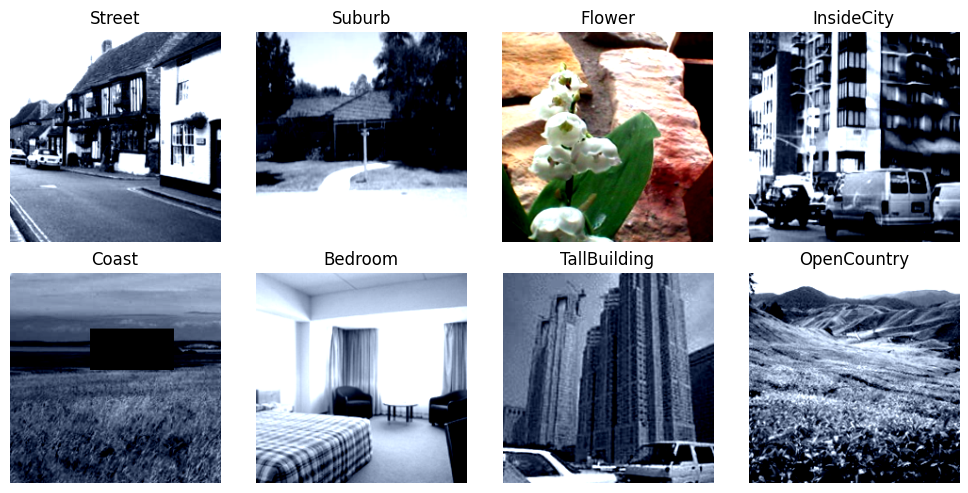

In [12]:
# Visualize a few training examples
images, labels = next(iter(train_loader))

fig, axes = plt.subplots(2, 4, figsize=(10, 5))
for ax, image, label in zip(axes.flat, images[:8], labels[:8]):
    image = image * 0.5 + 0.5  # unnormalize
    ax.imshow(image.permute(1, 2, 0))
    ax.set_title(class_names[label.item()])
    ax.axis('off')
plt.tight_layout()
plt.show()

## 3. Training & Evaluation


In [13]:
class ConvNeXt_Tiny(nn.Module):
    def __init__(self, num_classes=16):
        super().__init__()
        self.model = convnext_tiny(weights=ConvNeXt_Tiny_Weights.IMAGENET1K_V1)
    def forward(self, x):
        return self.model(x)

In [14]:
@torch.inference_mode()
def evaluate(model, loader, device):
    model.eval()
    correct = 0
    total = 0
    running_loss = 0.0
    criterion = nn.CrossEntropyLoss()

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        logits = model(images)
        loss = criterion(logits, labels)
        running_loss += loss.item() * images.size(0)
        correct += (logits.argmax(dim=1) == labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total


def train_model(model, train_loader, val_loader, optimizer, epochs=20, device=device):
    best_state = copy.deepcopy(model.state_dict())
    best_val_acc = 0.0
    history = {'train_loss': [], 'val_loss': [], 'val_acc': []}
    start = time.time()

    for epoch in range(1, epochs + 1):
        model.train()
        total_loss = 0.0
        total_seen = 0

        for images, labels in train_loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)
            logits = model(images)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item() * images.size(0)
            total_seen += labels.size(0)

        train_loss = total_loss / total_seen
        val_loss, val_acc = evaluate(model, val_loader, device)
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = copy.deepcopy(model.state_dict())

        elapsed = time.time() - start
        print(f'Epoch {epoch:02d}/{epochs} | '
              f'train loss {train_loss:.4f} | val loss {val_loss:.4f} | '
              f'val acc {val_acc:.4f} | {elapsed:.1f}s')

    model.load_state_dict(best_state)
    print(f'Best validation accuracy: {best_val_acc:.4f}')
    return model, history

In [15]:
# Train the model
set_random_seed(SEED)

model = ConvNeXt_Tiny(num_classes=num_classes)

# Freeze backbone parameters for initial warm-up
for param in model.parameters():
  param.requires_grad = False

# Replace classifier head for 16 classes
in_features = model.model.classifier[2].in_features
model.model.classifier[2] = nn.Linear(in_features, num_classes)

model = model.to(device)

# Loss function with label smoothing
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

# Unfreeze all layers
for param in model.parameters():
    param.requires_grad = True

# Lower learning rate for fine-tuning
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-2)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20)

model, history = train_model(
    model, train_loader, val_loader, optimizer, epochs=20, device=device
)

Downloading: "https://download.pytorch.org/models/convnext_tiny-983f1562.pth" to /root/.cache/torch/hub/checkpoints/convnext_tiny-983f1562.pth


100%|██████████| 109M/109M [00:00<00:00, 236MB/s] 


Epoch 01/20 | train loss 1.6346 | val loss 0.5175 | val acc 0.9271 | 925.0s
Epoch 02/20 | train loss 0.7905 | val loss 0.2599 | val acc 0.9542 | 933.0s
Epoch 03/20 | train loss 0.6753 | val loss 0.2195 | val acc 0.9625 | 940.9s
Epoch 04/20 | train loss 0.6299 | val loss 0.2663 | val acc 0.9437 | 948.9s
Epoch 05/20 | train loss 0.6157 | val loss 0.2250 | val acc 0.9604 | 956.8s
Epoch 06/20 | train loss 0.5986 | val loss 0.2164 | val acc 0.9708 | 964.7s
Epoch 07/20 | train loss 0.5951 | val loss 0.2245 | val acc 0.9604 | 972.6s
Epoch 08/20 | train loss 0.5876 | val loss 0.2226 | val acc 0.9625 | 980.6s
Epoch 09/20 | train loss 0.5846 | val loss 0.2090 | val acc 0.9646 | 988.5s
Epoch 10/20 | train loss 0.5937 | val loss 0.2563 | val acc 0.9521 | 996.6s
Epoch 11/20 | train loss 0.5841 | val loss 0.2180 | val acc 0.9646 | 1004.6s
Epoch 12/20 | train loss 0.5804 | val loss 0.2293 | val acc 0.9583 | 1012.5s
Epoch 13/20 | train loss 0.5788 | val loss 0.2132 | val acc 0.9667 | 1020.4s
Epoch 14/

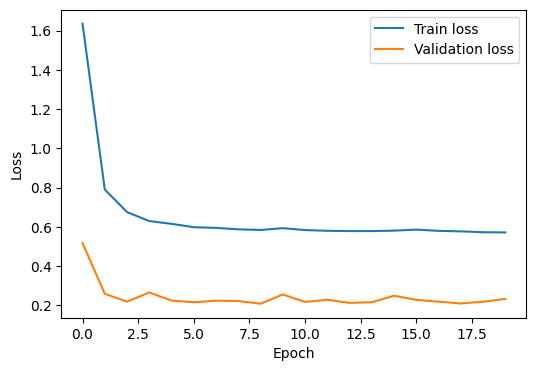

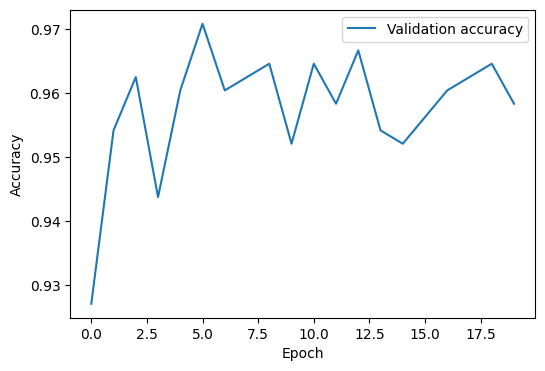

In [16]:
# Plot the training history.
plt.figure(figsize=(6, 4))
plt.plot(history['train_loss'], label='Train loss')
plt.plot(history['val_loss'], label='Validation loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(history['val_acc'], label='Validation accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()